# Notebook 03 — Dudas Metodológicas Adicionales

**Objetivo:** Investigar puntos críticos identificados en NB01 y NB02 que podrían afectar
el rendimiento del pipeline propuesto.

### Preguntas clave:
1. **Zero-inflation en Clover**: ¿Cómo afecta el 37.8% de ceros al entrenamiento y predicción?
2. **Transformaciones alternativas**: ¿Es log(1+y) la mejor opción? ¿Qué pasa con sqrt, Box-Cox, sinh⁻¹?
3. **Desbalance de estados entre folds**: ¿Cuánto afecta a la métrica R²?
4. **Varianza inter-fold**: ¿Qué folds son más difíciles y por qué?
5. **Análisis de outliers**: ¿Cuántos hay y cuánto peso tienen en la métrica final?
6. **Cabeza MLP**: ¿Cuál es el tamaño óptimo dado el ratio datos/params?

In [2]:
# --- Setup ---
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import GroupKFold
from pathlib import Path

NOTEBOOK_DIR = Path('.').resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / 'data'
FIG_DIR      = PROJECT_DIR / 'docs' / 'figures'

PRIMARY_TARGETS = ['Dry_Green_g', 'Dry_Clover_g', 'Dry_Dead_g']
ALL_TARGETS = PRIMARY_TARGETS + ['GDM_g', 'Dry_Total_g']

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

# Cargar datos — columnas reales: sample_id, image_path, Sampling_Date, State, Species,
# Pre_GSHH_NDVI, Height_Ave_cm, target_name, target
train_long = pd.read_csv(DATA_DIR / 'train.csv')

# Extraer ID limpio desde sample_id (formato: ID1011485656__Dry_Clover_g → ID1011485656)
train_long['ID'] = train_long['sample_id'].str.split('__').str[0]

# Pivotar de long a wide
df = train_long.pivot_table(index=['ID', 'State', 'Species', 'Sampling_Date', 'Pre_GSHH_NDVI', 'Height_Ave_cm'],
                            columns='target_name', values='target').reset_index()
df.columns.name = None
print(f"Dataset cargado: {len(df)} imágenes, {len(PRIMARY_TARGETS)} targets primarios")
print(f"Columnas: {df.columns.tolist()}")

Dataset cargado: 357 imágenes, 3 targets primarios
Columnas: ['ID', 'State', 'Species', 'Sampling_Date', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']


---
## 1. Zero-Inflation en Dry_Clover_g

**Pregunta:** El 37.8% de ceros en Clover es una proporción alta. ¿Cómo se refleja en la distribución
tras log-transform y qué implicaciones tiene para el entrenamiento?

In [3]:
# --- Análisis detallado de ceros por target ---
print("Tabla 1: Proporción de ceros por target\n")
for col in PRIMARY_TARGETS:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    print(f"  {col:15s}: {n_zeros:3d} ceros ({pct:5.1f}%)")

print(f"\n--- Análisis cruzado de ceros ---")
# ¿Las muestras con Clover=0 tienen distribuciones diferentes de Green/Dead?
clover_zero = df[df['Dry_Clover_g'] == 0]
clover_nonzero = df[df['Dry_Clover_g'] > 0]

print(f"\nMuestras con Clover = 0: {len(clover_zero)} ({len(clover_zero)/len(df)*100:.1f}%)")
print(f"Muestras con Clover > 0: {len(clover_nonzero)} ({len(clover_nonzero)/len(df)*100:.1f}%)")

print(f"\nComparación de medias (Green, Dead) según Clover:")
for col in ['Dry_Green_g', 'Dry_Dead_g']:
    m0 = clover_zero[col].mean()
    m1 = clover_nonzero[col].mean()
    print(f"  {col}: Clover=0 → media={m0:.2f}g | Clover>0 → media={m1:.2f}g | ratio={m1/m0:.2f}")

# ¿De qué estados vienen los ceros?
print(f"\nDistribución de Clover=0 por estado:")
print(clover_zero['State'].value_counts().to_string())
print(f"\nDistribución de Clover>0 por estado:")
print(clover_nonzero['State'].value_counts().to_string())

Tabla 1: Proporción de ceros por target

  Dry_Green_g    :  18 ceros (  5.0%)
  Dry_Clover_g   : 135 ceros ( 37.8%)
  Dry_Dead_g     :  40 ceros ( 11.2%)

--- Análisis cruzado de ceros ---

Muestras con Clover = 0: 135 (37.8%)
Muestras con Clover > 0: 222 (62.2%)

Comparación de medias (Green, Dead) según Clover:
  Dry_Green_g: Clover=0 → media=41.36g | Clover>0 → media=17.67g | ratio=0.43
  Dry_Dead_g: Clover=0 → media=14.89g | Clover>0 → media=10.31g | ratio=0.69

Distribución de Clover=0 por estado:
State
NSW    74
Tas    43
Vic    14
WA      4

Distribución de Clover>0 por estado:
State
Vic    98
Tas    95
WA     28
NSW     1


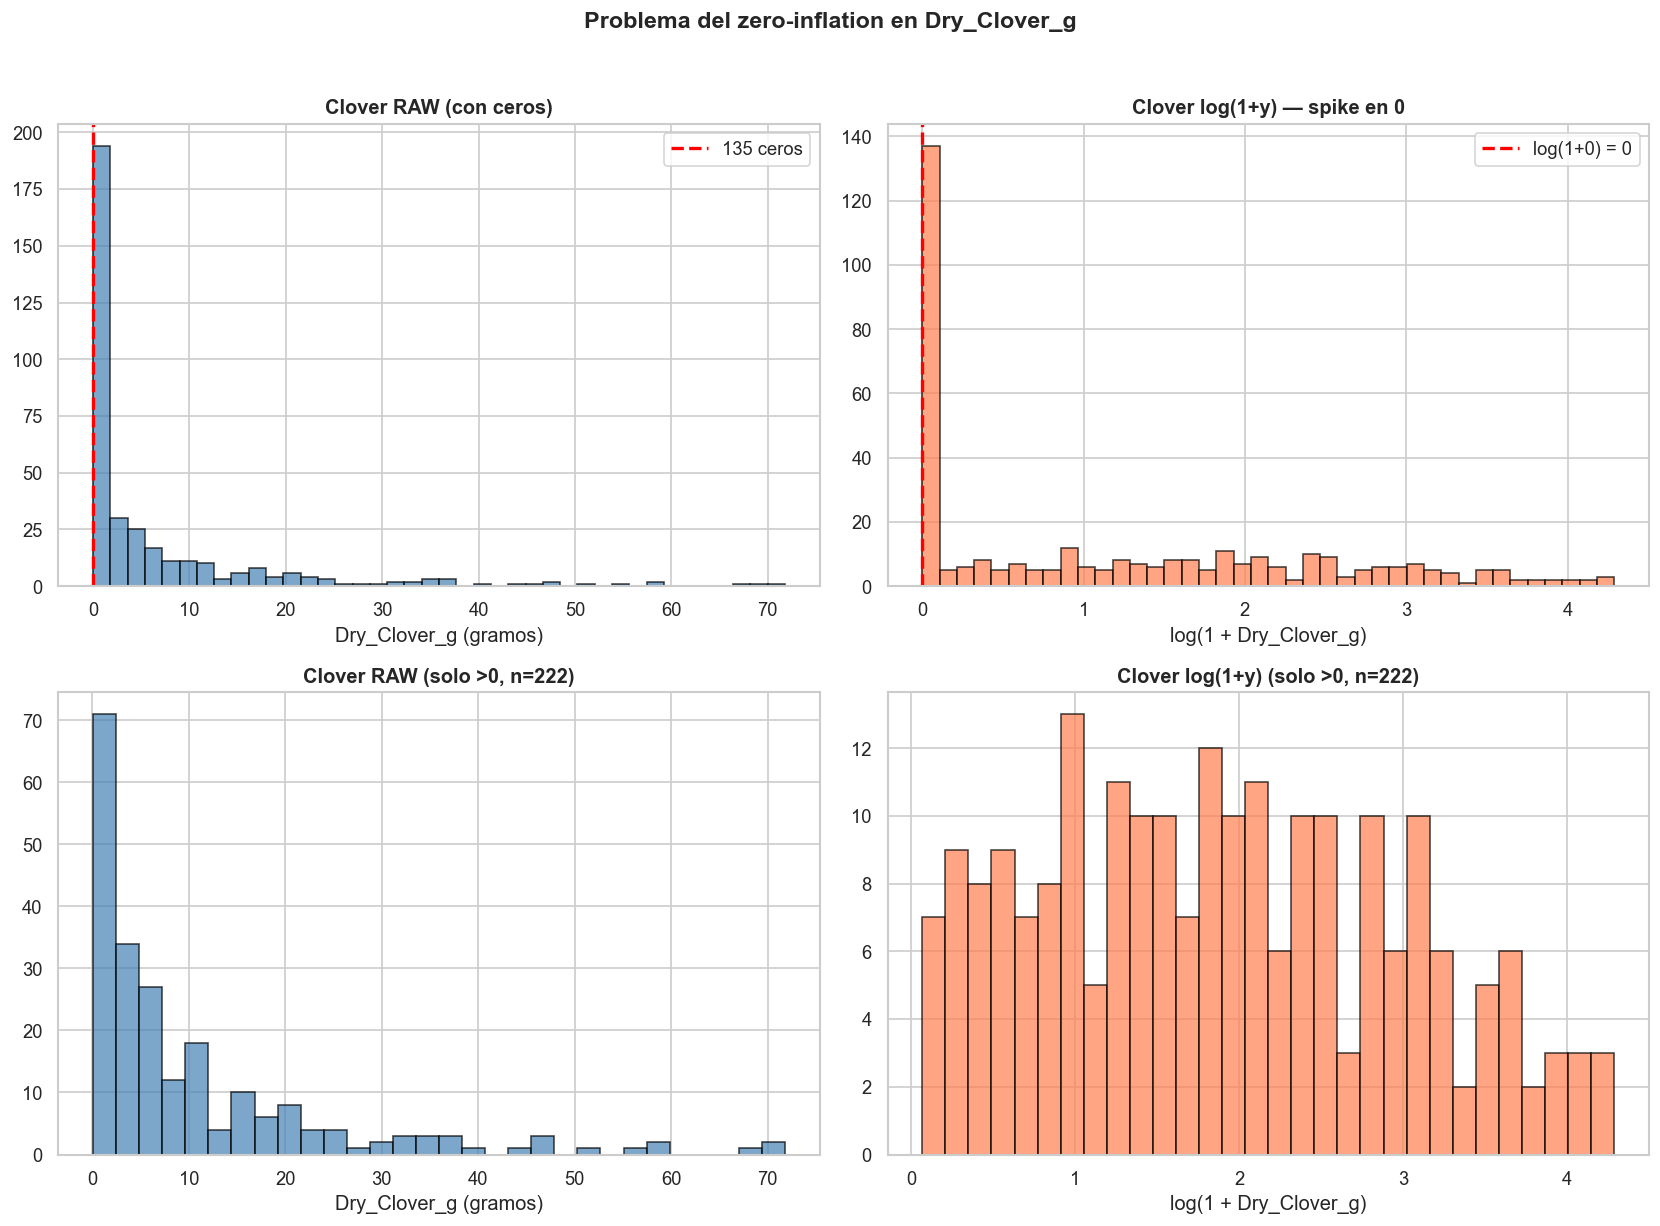

In [4]:
# --- Visualización: distribución de Clover con y sin ceros, raw vs log ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Raw con ceros
axes[0, 0].hist(df['Dry_Clover_g'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', ls='--', lw=2, label=f'{(df["Dry_Clover_g"]==0).sum()} ceros')
axes[0, 0].set_title('Clover RAW (con ceros)', fontweight='bold')
axes[0, 0].set_xlabel('Dry_Clover_g (gramos)')
axes[0, 0].legend()

# Log con ceros → spike at 0
axes[0, 1].hist(np.log1p(df['Dry_Clover_g']), bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', ls='--', lw=2, label='log(1+0) = 0')
axes[0, 1].set_title('Clover log(1+y) — spike en 0', fontweight='bold')
axes[0, 1].set_xlabel('log(1 + Dry_Clover_g)')
axes[0, 1].legend()

# Solo valores > 0 raw
clover_pos = df['Dry_Clover_g'][df['Dry_Clover_g'] > 0]
axes[1, 0].hist(clover_pos, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title(f'Clover RAW (solo >0, n={len(clover_pos)})', fontweight='bold')
axes[1, 0].set_xlabel('Dry_Clover_g (gramos)')

# Solo valores > 0 log
axes[1, 1].hist(np.log1p(clover_pos), bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title(f'Clover log(1+y) (solo >0, n={len(clover_pos)})', fontweight='bold')
axes[1, 1].set_xlabel('log(1 + Dry_Clover_g)')

fig.suptitle('Problema del zero-inflation en Dry_Clover_g', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_clover_zero_inflation.png', bbox_inches='tight')
plt.show()

In [21]:
# --- Impacto del spike en 0 sobre la estandarización ---
# Con 37.8% de los valores en log(1+0)=0, la media y la std se ven afectadas
y_log_clover = np.log1p(df['Dry_Clover_g'])
mu = y_log_clover.mean()
sigma = y_log_clover.std()
y_std_clover = (y_log_clover - mu) / sigma

# Valor estandarizado de los ceros
zero_std_value = (0 - mu) / sigma

print(f"Estadísticos de Clover tras log(1+y):")
print(f"  Media: {mu:.4f}")
print(f"  Std:   {sigma:.4f}")
print(f"  Valor estandarizado de los ceros: {zero_std_value:.4f}")
print(f"  → Los {(df['Dry_Clover_g']==0).sum()} ceros se mapean a z = {zero_std_value:.2f}")
print(f"  → Esto crea un pico discreto en z = {zero_std_value:.2f} que la red debe aprender")

Estadísticos de Clover tras log(1+y):
  Media: 1.1740
  Std:   1.2461
  Valor estandarizado de los ceros: -0.9422
  → Los 135 ceros se mapean a z = -0.94
  → Esto crea un pico discreto en z = -0.94 que la red debe aprender


---
## 2. Transformaciones Alternativas

**Pregunta:** ¿Log(1+y) es la mejor transformación? Comparamos con sqrt(y), sinh⁻¹(y) y Box-Cox.

In [6]:
# --- Comparación de transformaciones ---
transforms = {
    'raw': lambda y: y,
    'log(1+y)': lambda y: np.log1p(y),
    'sqrt(y)': lambda y: np.sqrt(y),
    'arcsinh(y)': lambda y: np.arcsinh(y),
}

# Box-Cox requiere y > 0, se aplica solo a valores positivos
comparison = []
for col in PRIMARY_TARGETS:
    y = df[col]
    for name, fn in transforms.items():
        yt = fn(y)
        comparison.append({
            'Target': col,
            'Transform': name,
            'Skewness': round(yt.skew(), 3),
            '|Skewness|': round(abs(yt.skew()), 3),
            'Kurtosis': round(yt.kurtosis(), 3),
            'Pct_ceros_en_transform': round((yt == 0).sum() / len(yt) * 100, 1),
        })
    # Box-Cox solo para y > 0
    y_pos = y[y > 0]
    if len(y_pos) > 20:
        yt_bc, lam = stats.boxcox(y_pos)
        yt_bc_series = pd.Series(yt_bc)
        comparison.append({
            'Target': col,
            'Transform': f'Box-Cox(λ={lam:.2f})',
            'Skewness': round(yt_bc_series.skew(), 3),
            '|Skewness|': round(abs(yt_bc_series.skew()), 3),
            'Kurtosis': round(yt_bc_series.kurtosis(), 3),
            'Pct_ceros_en_transform': 0.0,  # Box-Cox excluye ceros
        })

comp_df = pd.DataFrame(comparison)
print("Tabla 2: Comparación de transformaciones\n")
for col in PRIMARY_TARGETS:
    print(f"\n--- {col} ---")
    subset = comp_df[comp_df['Target'] == col][['Transform', 'Skewness', '|Skewness|', 'Kurtosis', 'Pct_ceros_en_transform']]
    print(subset.to_string(index=False))

Tabla 2: Comparación de transformaciones


--- Dry_Green_g ---
      Transform  Skewness  |Skewness|  Kurtosis  Pct_ceros_en_transform
            raw     1.751       1.751     3.912                     5.0
       log(1+y)    -0.840       0.840     0.101                     5.0
        sqrt(y)     0.270       0.270     0.049                     5.0
     arcsinh(y)    -1.042       1.042     0.456                     5.0
Box-Cox(λ=0.33)    -0.041       0.041    -0.071                     0.0

--- Dry_Clover_g ---
      Transform  Skewness  |Skewness|  Kurtosis  Pct_ceros_en_transform
            raw     2.842       2.842     9.068                    37.8
       log(1+y)     0.690       0.690    -0.772                    37.8
        sqrt(y)     1.224       1.224     0.978                    37.8
     arcsinh(y)     0.573       0.573    -1.025                    37.8
Box-Cox(λ=0.11)    -0.033       0.033    -0.595                     0.0

--- Dry_Dead_g ---
      Transform  Skewness  |Ske

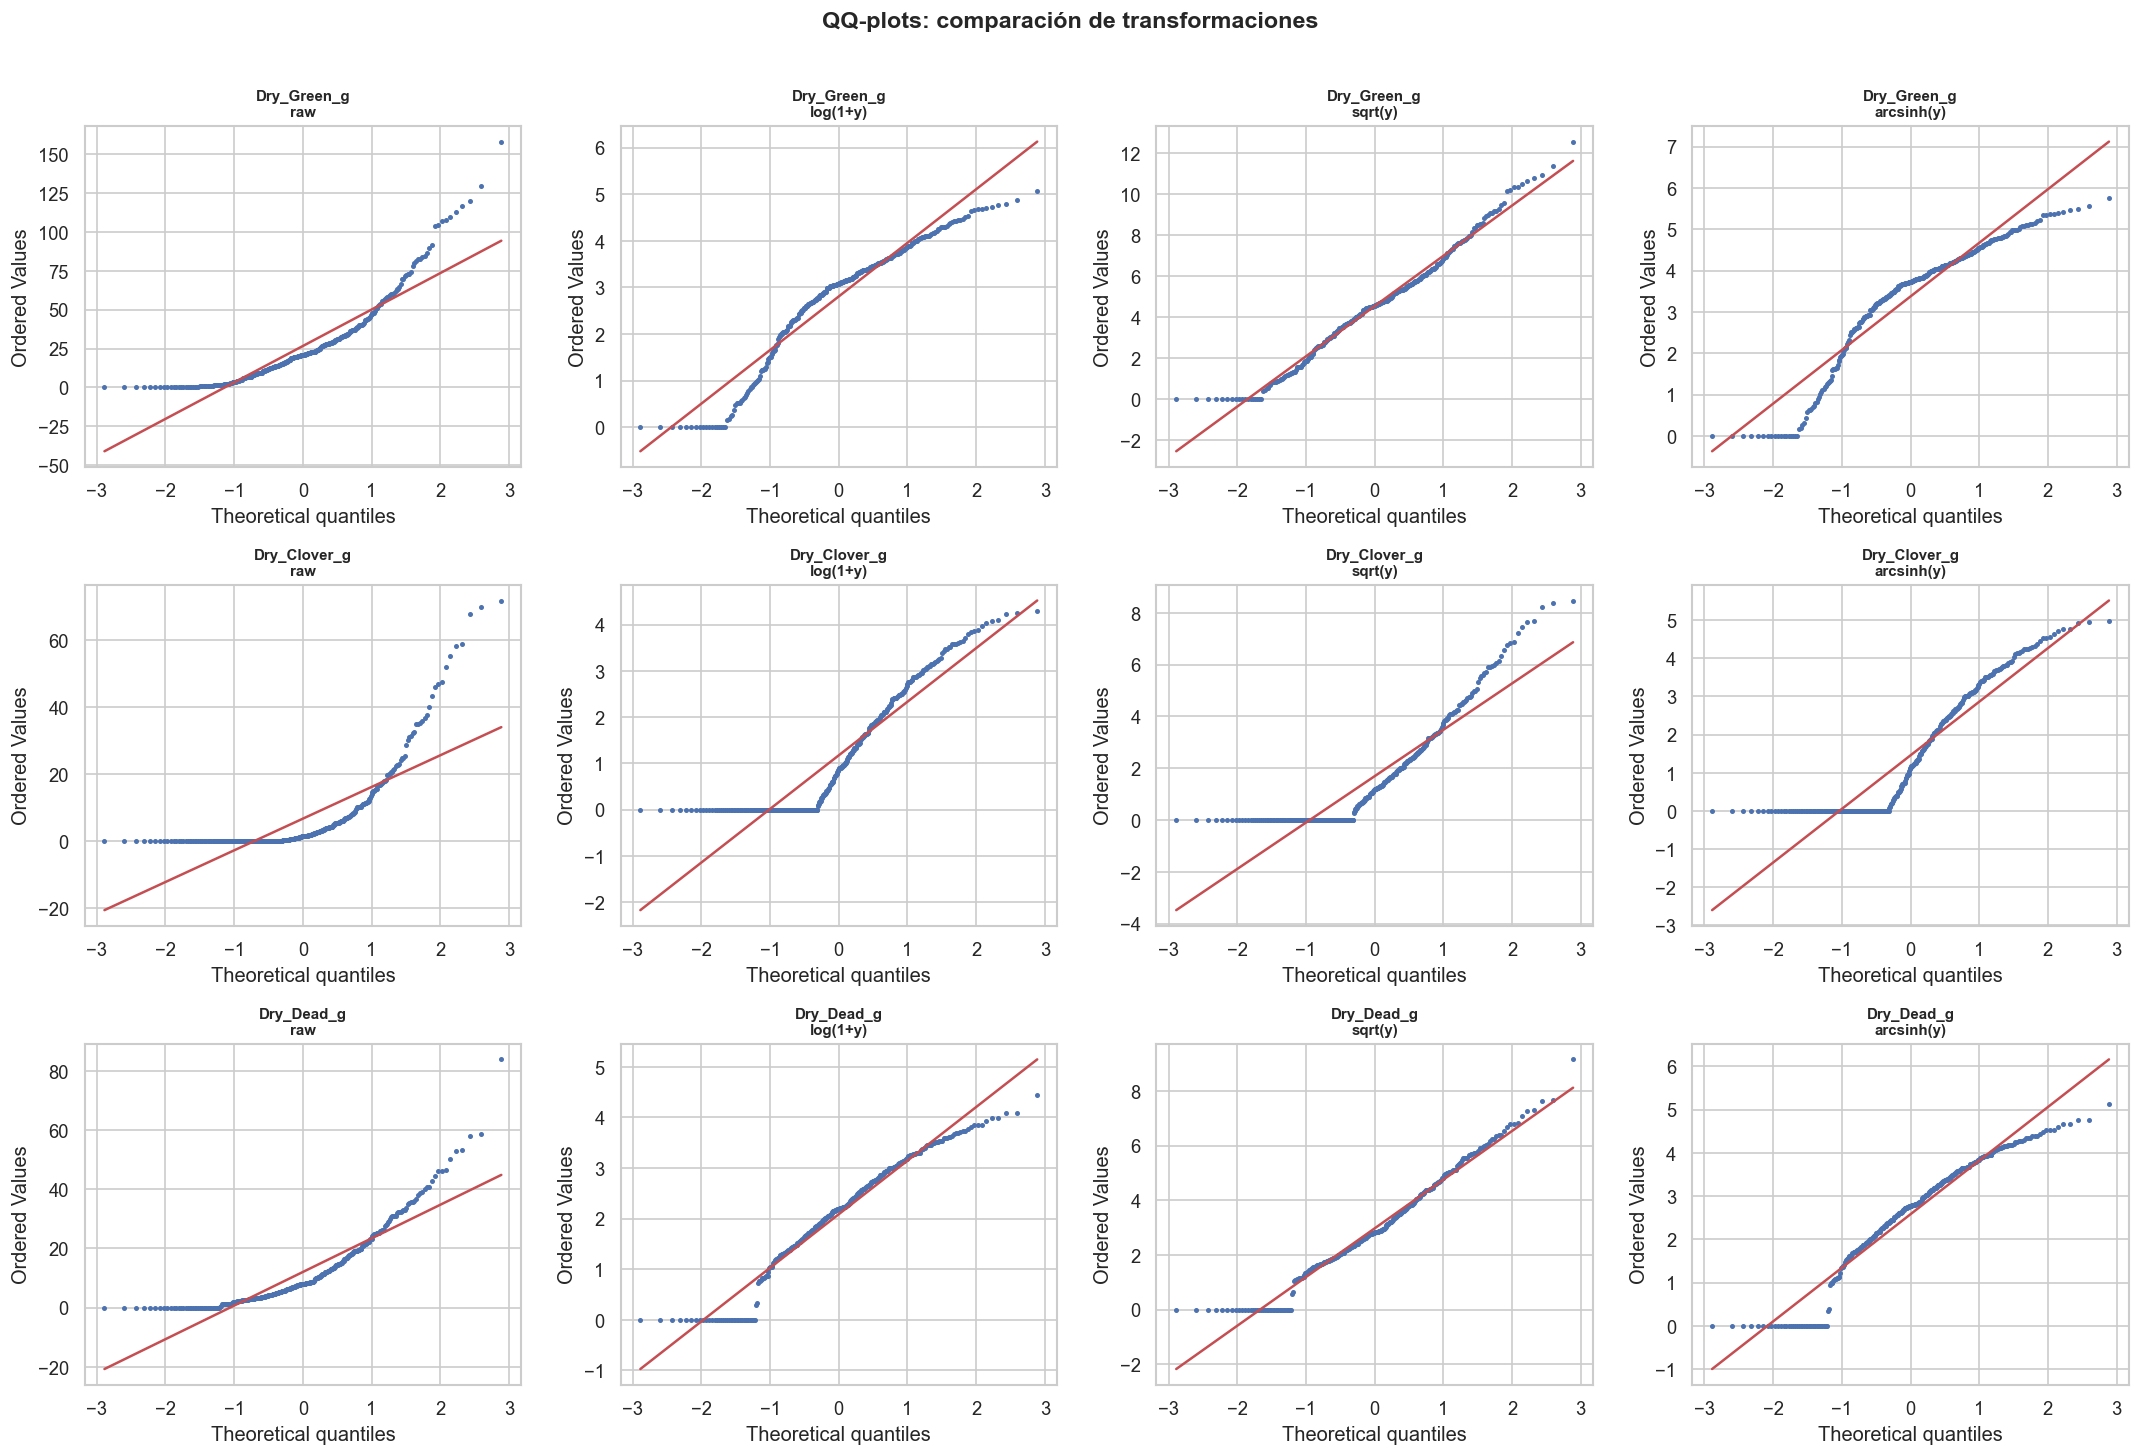


Mejor transformación por |skewness|:
  Dry_Clover_g: Box-Cox(λ=0.11) (|skew| = 0.033)
  Dry_Dead_g: Box-Cox(λ=0.13) (|skew| = 0.021)
  Dry_Green_g: Box-Cox(λ=0.33) (|skew| = 0.041)


In [7]:
# --- Visualización: QQ-plots de las 4 transformaciones para cada target ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
transform_names = list(transforms.keys())

for i, col in enumerate(PRIMARY_TARGETS):
    y = df[col]
    for j, (name, fn) in enumerate(transforms.items()):
        yt = fn(y)
        stats.probplot(yt, dist='norm', plot=axes[i, j])
        axes[i, j].set_title(f'{col}\n{name}', fontweight='bold', fontsize=9)
        axes[i, j].get_lines()[0].set_markersize(2)

fig.suptitle('QQ-plots: comparación de transformaciones', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_comparacion_transformaciones_qq.png', bbox_inches='tight')
plt.show()

# Conclusión basada en datos (se llena tras ejecución)
best_per_target = comp_df.loc[comp_df.groupby('Target')['|Skewness|'].idxmin()]
print("\nMejor transformación por |skewness|:")
for _, row in best_per_target.iterrows():
    print(f"  {row['Target']}: {row['Transform']} (|skew| = {row['|Skewness|']})")

In [8]:
# --- Análisis: ¿arcsinh es práctico como alternativa a log(1+y)? ---
print("Comparación directa log(1+y) vs arcsinh(y):\n")
for col in PRIMARY_TARGETS:
    y = df[col]
    y_log = np.log1p(y)
    y_asinh = np.arcsinh(y)
    
    # Correlación entre ambas transformaciones
    corr = np.corrcoef(y_log, y_asinh)[0, 1]
    diff_max = np.abs(y_log - y_asinh).max()
    diff_mean = np.abs(y_log - y_asinh).mean()
    
    print(f"{col}:")
    print(f"  Correlación: {corr:.6f}")
    print(f"  Diferencia máx: {diff_max:.4f}, media: {diff_mean:.4f}")
    print(f"  Skew log: {y_log.skew():.3f} vs arcsinh: {y_asinh.skew():.3f}")
    print()

Comparación directa log(1+y) vs arcsinh(y):

Dry_Green_g:
  Correlación: 0.998294
  Diferencia máx: 0.6868, media: 0.5665
  Skew log: -0.840 vs arcsinh: -1.042

Dry_Clover_g:
  Correlación: 0.998838
  Diferencia máx: 0.6794, media: 0.2817
  Skew log: 0.690 vs arcsinh: 0.573

Dry_Dead_g:
  Correlación: 0.998290
  Diferencia máx: 0.6813, media: 0.4948
  Skew log: -0.426 vs arcsinh: -0.624



---
## 3. Desbalance de Estados entre Folds

**Pregunta:** GroupKFold por fecha genera folds con distribución desigual de estados.
¿Cuánto afecta esto a la predicción?

In [9]:
# --- Análisis detallado de la composición de cada fold ---
gkf = GroupKFold(n_splits=5)
fold_details = []

for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(df, groups=df['Sampling_Date'])):
    val_df = df.iloc[val_idx]
    train_df = df.iloc[train_idx]
    
    # Estadísticos de targets en validación
    for col in PRIMARY_TARGETS:
        fold_details.append({
            'Fold': fold_idx + 1,
            'Target': col,
            'Val_n': len(val_df),
            'Val_mean': val_df[col].mean(),
            'Val_std': val_df[col].std(),
            'Val_median': val_df[col].median(),
            'Val_pct_zeros': (val_df[col] == 0).sum() / len(val_df) * 100,
            'States_in_val': ', '.join(sorted(val_df['State'].unique())),
            'N_species_val': val_df['Species'].nunique(),
        })

fd = pd.DataFrame(fold_details)
print("Tabla 3: Composición detallada de cada fold (validación)\n")

for fold in range(1, 6):
    sub = fd[fd['Fold'] == fold]
    states = sub['States_in_val'].iloc[0]
    n_val = sub['Val_n'].iloc[0]
    n_species = sub['N_species_val'].iloc[0]
    print(f"--- Fold {fold} (n_val={n_val}, states=[{states}], species={n_species}) ---")
    for _, row in sub.iterrows():
        print(f"  {row['Target']:15s}: mean={row['Val_mean']:6.2f}, std={row['Val_std']:6.2f}, "
              f"median={row['Val_median']:6.2f}, %zeros={row['Val_pct_zeros']:4.1f}%")
    print()

Tabla 3: Composición detallada de cada fold (validación)

--- Fold 1 (n_val=74, states=[Tas, Vic, WA], species=7) ---
  Dry_Green_g    : mean= 16.66, std= 15.34, median= 13.84, %zeros=10.8%
  Dry_Clover_g   : mean=  9.45, std= 14.32, median=  2.80, %zeros=17.6%
  Dry_Dead_g     : mean= 12.88, std= 10.68, median= 10.90, %zeros=10.8%

--- Fold 2 (n_val=68, states=[NSW, Tas], species=5) ---
  Dry_Green_g    : mean= 42.00, std= 35.95, median= 31.94, %zeros= 0.0%
  Dry_Clover_g   : mean=  1.34, std=  3.45, median=  0.00, %zeros=73.5%
  Dry_Dead_g     : mean= 14.12, std= 13.31, median=  9.16, %zeros= 8.8%

--- Fold 3 (n_val=74, states=[NSW, Tas, Vic, WA], species=7) ---
  Dry_Green_g    : mean= 20.07, std= 23.40, median= 13.80, %zeros=13.5%
  Dry_Clover_g   : mean= 11.53, std= 16.06, median=  5.67, %zeros=27.0%
  Dry_Dead_g     : mean= 12.88, std= 13.05, median=  8.46, %zeros=17.6%

--- Fold 4 (n_val=73, states=[NSW, Tas, Vic, WA], species=6) ---
  Dry_Green_g    : mean= 23.96, std= 21.13, m

C:\Users\n_ala\AppData\Local\Temp\ipykernel_15376\2993448420.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fold_df, x='Fold', y=col, ax=axes[i], palette='Set2')
C:\Users\n_ala\AppData\Local\Temp\ipykernel_15376\2993448420.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fold_df, x='Fold', y=col, ax=axes[i], palette='Set2')
C:\Users\n_ala\AppData\Local\Temp\ipykernel_15376\2993448420.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fold_df, x='Fold', y=col, ax=axes[i], palette='Set2')


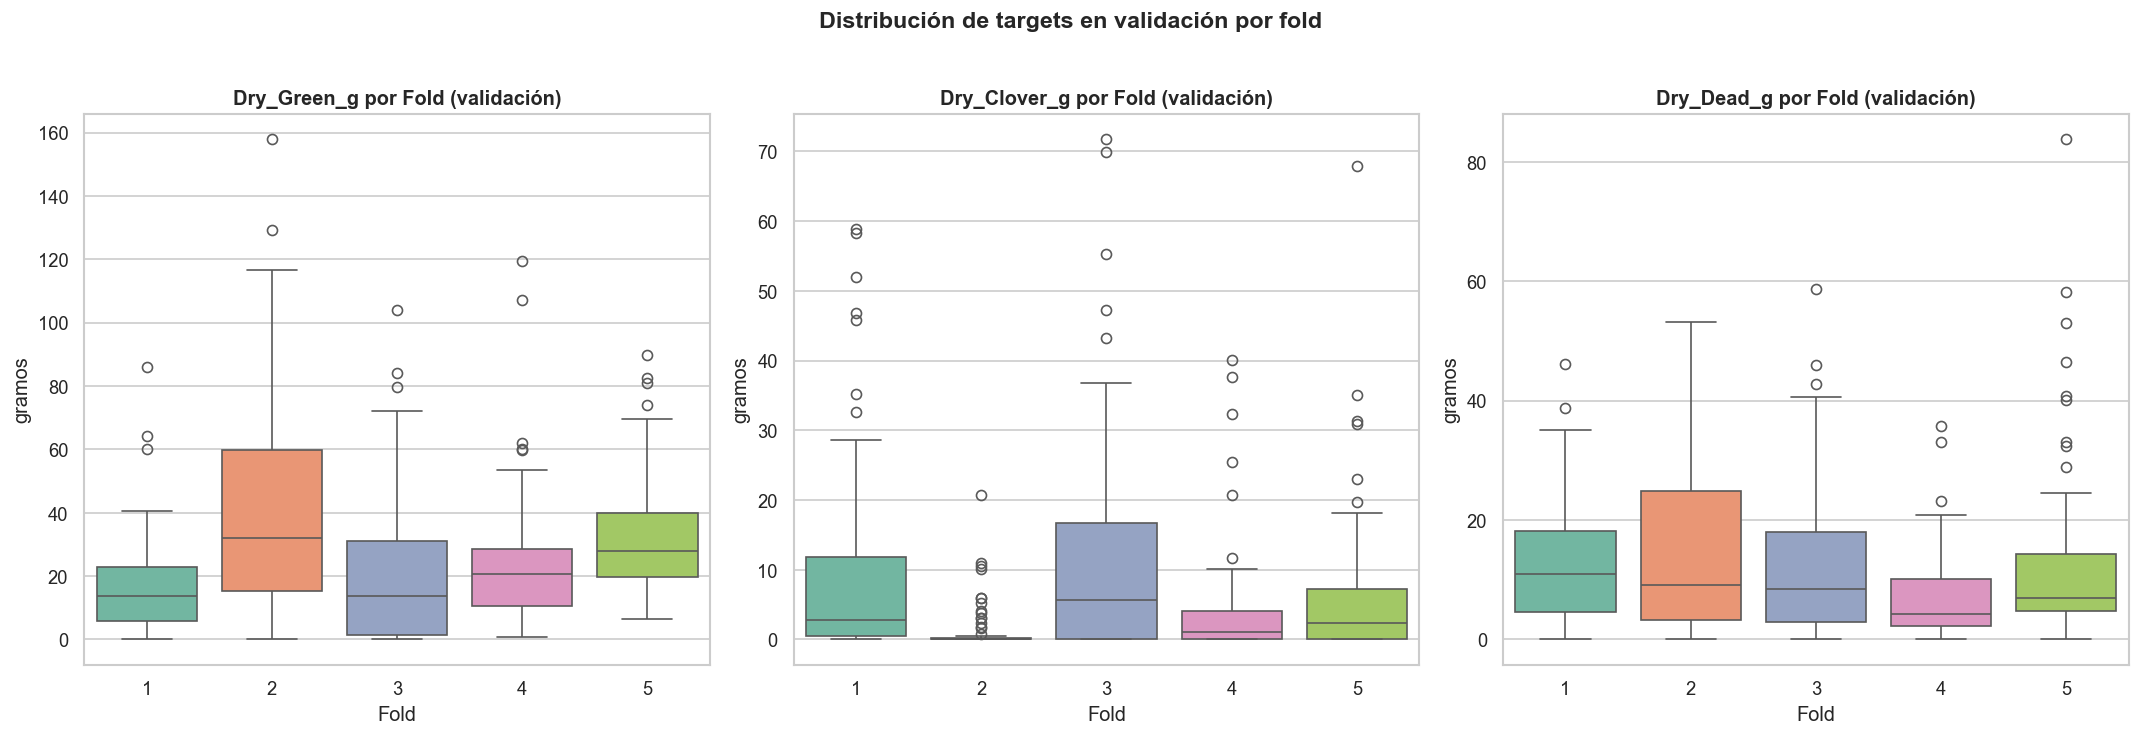

In [10]:
# --- Visualización: distribución de targets por fold en validación ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

gkf = GroupKFold(n_splits=5)
fold_data = []
for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(df, groups=df['Sampling_Date'])):
    val = df.iloc[val_idx].copy()
    val['Fold'] = fold_idx + 1
    fold_data.append(val)
fold_df = pd.concat(fold_data)

for i, col in enumerate(PRIMARY_TARGETS):
    sns.boxplot(data=fold_df, x='Fold', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} por Fold (validación)', fontweight='bold')
    axes[i].set_ylabel('gramos')

fig.suptitle('Distribución de targets en validación por fold', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_targets_por_fold.png', bbox_inches='tight')
plt.show()

In [11]:
# --- ¿Cuánto difieren las distribuciones de targets entre estados? ---
print("Tabla 4: Estadísticos de targets por estado\n")
for col in PRIMARY_TARGETS:
    print(f"\n--- {col} ---")
    state_stats = df.groupby('State')[col].agg(['mean', 'std', 'median', 'count'])
    state_stats['pct_zeros'] = df.groupby('State').apply(lambda g: (g[col] == 0).sum() / len(g) * 100)
    print(state_stats.round(2).to_string())

# Test Kruskal-Wallis: ¿hay diferencia significativa entre estados?
print("\n--- Test Kruskal-Wallis (H₀: distribuciones iguales entre estados) ---")
for col in PRIMARY_TARGETS:
    groups = [group[col].values for _, group in df.groupby('State')]
    h_stat, p_val = stats.kruskal(*groups)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f"  {col}: H={h_stat:.2f}, p={p_val:.4e} {sig}")

Tabla 4: Estadísticos de targets por estado


--- Dry_Green_g ---
        mean    std  median  count  pct_zeros
State                                        
NSW    56.56  31.23   53.50     75       0.00
Tas    15.33  13.11   12.98    138       1.45
Vic    25.45  16.02   21.59    112       0.00
WA      9.30  18.79    0.35     32      50.00

--- Dry_Clover_g ---
        mean    std  median  count  pct_zeros
State                                        
NSW     0.13   1.17    0.00     75      98.67
Tas     6.24  11.61    1.08    138      31.16
Vic     7.11   9.57    4.05    112      12.50
WA     22.09  20.21   15.60     32      12.50

--- Dry_Dead_g ---
        mean    std  median  count  pct_zeros
State                                        
NSW    14.20  15.63    8.36     75       9.33
Tas    15.23  12.43   11.07    138       0.00
Vic    10.11   8.86    7.22    112       0.89
WA      0.00   0.00    0.00     32     100.00

--- Test Kruskal-Wallis (H₀: distribuciones iguales entre estad

C:\Users\n_ala\AppData\Local\Temp\ipykernel_15376\571131697.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_stats['pct_zeros'] = df.groupby('State').apply(lambda g: (g[col] == 0).sum() / len(g) * 100)
C:\Users\n_ala\AppData\Local\Temp\ipykernel_15376\571131697.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_stats['pct_zeros'] = df.groupby('State').apply(lambda g: (g[col] == 0).sum() / len(g) * 100

---
## 4. Impacto de Outliers en la Métrica Final

**Pregunta:** ¿Cuántos outliers hay (por IQR) y cuánto impacto tienen
en R² y en el score final ponderado?

In [12]:
# --- Análisis de outliers por IQR y su impacto ---
print("Tabla 5: Outliers por IQR (>1.5×IQR desde Q1/Q3)\n")

outlier_analysis = []
for col in ALL_TARGETS:
    y = df[col]
    Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = y[(y < lower) | (y > upper)]
    
    outlier_analysis.append({
        'Target': col,
        'N_outliers': len(outliers),
        'Pct_outliers': round(len(outliers) / len(y) * 100, 1),
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Upper_limit': round(upper, 2),
        'Outlier_mean': round(outliers.mean(), 2) if len(outliers) > 0 else None,
        'Outlier_max': round(outliers.max(), 2) if len(outliers) > 0 else None,
    })

oa_df = pd.DataFrame(outlier_analysis)
print(oa_df.to_string(index=False))

Tabla 5: Outliers por IQR (>1.5×IQR desde Q1/Q3)

      Target  N_outliers  Pct_outliers    Q1    Q3   IQR  Upper_limit  Outlier_mean  Outlier_max
 Dry_Green_g          20           5.6  8.80 35.08 26.28        74.51        100.41       157.98
Dry_Clover_g          41          11.5  0.00  7.24  7.24        18.11         34.86        71.79
  Dry_Dead_g          14           3.9  3.20 17.64 14.44        39.29         50.33        83.84
       GDM_g          16           4.5 16.03 43.68 27.65        85.15        108.55       157.98
 Dry_Total_g          16           4.5 25.27 57.88 32.61       106.79        124.57       185.70


In [13]:
# --- ¿Son los mismos outliers en todos los targets? ---
outlier_ids = {}
for col in PRIMARY_TARGETS:
    y = df[col]
    Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    outlier_ids[col] = set(df[y > upper].index)

# Overlap
all_outlier_idx = set()
for s in outlier_ids.values():
    all_outlier_idx |= s

print(f"Total de imágenes que son outlier en al menos 1 target: {len(all_outlier_idx)} / {len(df)}")
print(f"\nOverlap entre targets:")
for c1 in PRIMARY_TARGETS:
    for c2 in PRIMARY_TARGETS:
        if c1 < c2:
            overlap = outlier_ids[c1] & outlier_ids[c2]
            print(f"  {c1} ∩ {c2}: {len(overlap)} imágenes en común")

common_all = outlier_ids['Dry_Green_g'] & outlier_ids['Dry_Clover_g'] & outlier_ids['Dry_Dead_g']
print(f"\nOutlier en los 3 targets simultáneamente: {len(common_all)} imágenes")

# ¿De qué estados vienen?
if len(all_outlier_idx) > 0:
    outlier_df = df.loc[list(all_outlier_idx)]
    print(f"\nEstados de los outliers:")
    print(outlier_df['State'].value_counts().to_string())

Total de imágenes que son outlier en al menos 1 target: 74 / 357

Overlap entre targets:
  Dry_Clover_g ∩ Dry_Green_g: 0 imágenes en común
  Dry_Clover_g ∩ Dry_Dead_g: 0 imágenes en común
  Dry_Dead_g ∩ Dry_Green_g: 1 imágenes en común

Outlier en los 3 targets simultáneamente: 0 imágenes

Estados de los outliers:
State
Tas    24
NSW    21
WA     16
Vic    13


In [14]:
# --- Simulación: impacto de outliers en R² ---
# Si removemos los outliers del cálculo, ¿cuánto cambia R²?
from sklearn.metrics import r2_score

weights = {'Dry_Green_g': 0.1, 'Dry_Clover_g': 0.1, 'Dry_Dead_g': 0.1, 'GDM_g': 0.2, 'Dry_Total_g': 0.5}

# Simular predicciones perfectas excepto por noise
np.random.seed(42)
print("Simulación: predictor 'perfecto' con ruido N(0, σ) donde σ = 10% de la std\n")

for scenario_name, remove_outliers in [('Con outliers', False), ('Sin outliers', True)]:
    subset = df.copy()
    if remove_outliers:
        subset = subset.drop(list(all_outlier_idx))
    
    score = 0
    print(f"--- {scenario_name} (n={len(subset)}) ---")
    for col in ALL_TARGETS:
        y_true = subset[col].values
        noise = np.random.normal(0, y_true.std() * 0.10, size=len(y_true))
        y_pred = y_true + noise
        r2 = r2_score(y_true, y_pred)
        w = weights[col]
        score += w * r2
        print(f"  {col:15s}: R² = {r2:.4f} (peso {w})")
    print(f"  Score ponderado: {score:.4f}\n")

Simulación: predictor 'perfecto' con ruido N(0, σ) donde σ = 10% de la std

--- Con outliers (n=357) ---
  Dry_Green_g    : R² = 0.9910 (peso 0.1)
  Dry_Clover_g   : R² = 0.9895 (peso 0.1)
  Dry_Dead_g     : R² = 0.9907 (peso 0.1)
  GDM_g          : R² = 0.9896 (peso 0.2)
  Dry_Total_g    : R² = 0.9901 (peso 0.5)
  Score ponderado: 0.9901

--- Sin outliers (n=283) ---
  Dry_Green_g    : R² = 0.9904 (peso 0.1)
  Dry_Clover_g   : R² = 0.9906 (peso 0.1)
  Dry_Dead_g     : R² = 0.9904 (peso 0.1)
  GDM_g          : R² = 0.9901 (peso 0.2)
  Dry_Total_g    : R² = 0.9899 (peso 0.5)
  Score ponderado: 0.9901



---
## 5. Análisis de la Cabeza MLP

**Pregunta:** ¿Cuál es el tamaño óptimo de la cabeza MLP dado que el ratio datos/params < 1?

In [15]:
# --- Explorar diferentes tamaños de cabeza ---
import torch.nn as nn

# Dimensiones de feature de cada backbone
backbone_dims = {
    'ResNet50': 2048,
    'EfficientNet-B2': 1408,
    'ConvNeXt-Tiny': 768,
    'MaxViT-Tiny': 512,
    'ViT-Small': 384,
    'Swin-Tiny': 768,
}

# La cabeza actual: Linear(dim_in, 128) → ReLU → Dropout(0.3) → Linear(128, 3)
# Alternativas: variar la capa oculta
hidden_sizes = [32, 64, 128, 256, 512]
n_out = 3  # 3 targets primarios
n_train = int(357 * 0.8)  # ~285 muestras de entrenamiento

print("Tabla 6: Parámetros entrenables de la cabeza MLP por arquitectura y hidden_size\n")
results = []
for model, dim_in in backbone_dims.items():
    for h in hidden_sizes:
        # params = dim_in * h + h (bias) + h * n_out + n_out (bias)
        total_params = dim_in * h + h + h * n_out + n_out
        ratio = n_train / total_params
        results.append({
            'Modelo': model,
            'Dim_in': dim_in,
            'Hidden': h,
            'Params': total_params,
            'Ratio_datos/params': round(ratio, 3),
        })

res_df = pd.DataFrame(results)
pivot = res_df.pivot_table(index='Modelo', columns='Hidden', values='Params', aggfunc='first')
print("Params por (Modelo × Hidden):")
print(pivot.to_string())

print("\nRatio datos/params:")
pivot_ratio = res_df.pivot_table(index='Modelo', columns='Hidden', values='Ratio_datos/params', aggfunc='first')
print(pivot_ratio.to_string())

Tabla 6: Parámetros entrenables de la cabeza MLP por arquitectura y hidden_size

Params por (Modelo × Hidden):
Hidden             32      64      128     256      512
Modelo                                                 
ConvNeXt-Tiny    24707   49411   98819  197635   395267
EfficientNet-B2  45187   90371  180739  361475   722947
MaxViT-Tiny      16515   33027   66051  132099   264195
ResNet50         65667  131331  262659  525315  1050627
Swin-Tiny        24707   49411   98819  197635   395267
ViT-Small        12419   24835   49667   99331   198659

Ratio datos/params:
Hidden             32     64     128    256    512
Modelo                                            
ConvNeXt-Tiny    0.012  0.006  0.003  0.001  0.001
EfficientNet-B2  0.006  0.003  0.002  0.001  0.000
MaxViT-Tiny      0.017  0.009  0.004  0.002  0.001
ResNet50         0.004  0.002  0.001  0.001  0.000
Swin-Tiny        0.012  0.006  0.003  0.001  0.001
ViT-Small        0.023  0.011  0.006  0.003  0.001


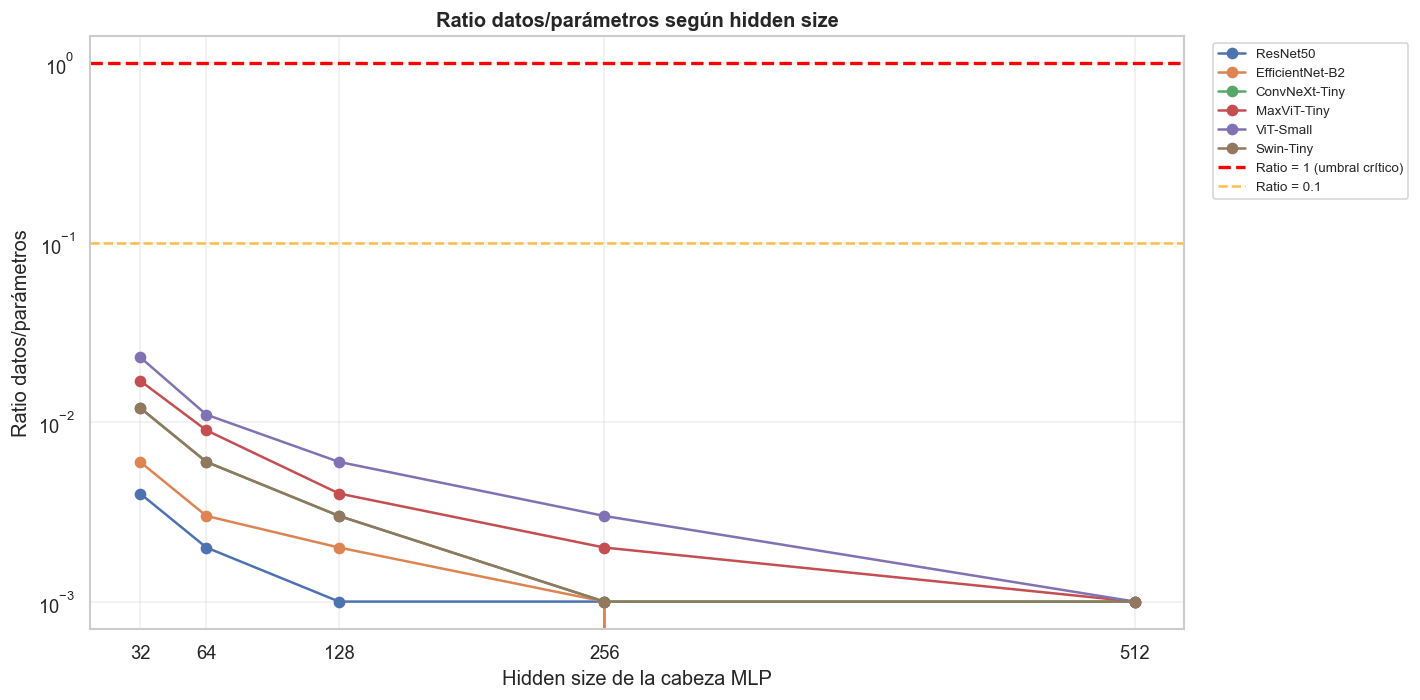


Análisis:
  Ninguna configuración alcanza ratio ≥ 1.
  Top-5 ratios:
    ViT-Small            hidden= 32 → ratio=0.023, params=12,419
    MaxViT-Tiny          hidden= 32 → ratio=0.017, params=16,515
    ConvNeXt-Tiny        hidden= 32 → ratio=0.012, params=24,707
    Swin-Tiny            hidden= 32 → ratio=0.012, params=24,707
    ViT-Small            hidden= 64 → ratio=0.011, params=24,835


In [16]:
# --- Visualización: ratio datos/params por configuración ---
fig, ax = plt.subplots(figsize=(12, 6))

for model in backbone_dims:
    sub = res_df[res_df['Modelo'] == model]
    ax.plot(sub['Hidden'], sub['Ratio_datos/params'], 'o-', label=model, markersize=6)

ax.axhline(1.0, color='red', ls='--', lw=2, label='Ratio = 1 (umbral crítico)')
ax.axhline(0.1, color='orange', ls='--', lw=1.5, alpha=0.7, label='Ratio = 0.1')
ax.set_xlabel('Hidden size de la cabeza MLP')
ax.set_ylabel('Ratio datos/parámetros')
ax.set_title('Ratio datos/parámetros según hidden size', fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_yscale('log')
ax.set_xticks(hidden_sizes)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / '03_ratio_datos_params_hidden.png', bbox_inches='tight')
plt.show()

# Conclusión basada en datos
print("\nAnálisis:")
# Encontrar hidden sizes donde ratio > 1 para algún modelo
above_1 = res_df[res_df['Ratio_datos/params'] >= 1.0]
if len(above_1) > 0:
    print(f"  Configuraciones con ratio ≥ 1: {len(above_1)}")
    for _, r in above_1.iterrows():
        print(f"    {r['Modelo']:20s} hidden={r['Hidden']:3d} → ratio={r['Ratio_datos/params']:.3f}")
else:
    print("  Ninguna configuración alcanza ratio ≥ 1.")
    # Encontrar las mejores
    best = res_df.sort_values('Ratio_datos/params', ascending=False).head(5)
    print("  Top-5 ratios:")
    for _, r in best.iterrows():
        print(f"    {r['Modelo']:20s} hidden={r['Hidden']:3d} → ratio={r['Ratio_datos/params']:.3f}, params={r['Params']:,}")

In [23]:
# --- ¿Y una cabeza directa (sin capa oculta)? ---
print("Tabla 7: Cabeza directa (Linear sin capa oculta)\n")
for model, dim_in in backbone_dims.items():
    # Solo: Linear(dim_in, 3) → params = dim_in * 3 + 3
    params_direct = dim_in * n_out + n_out
    ratio_direct = n_train / params_direct
    
    # Cabeza con hidden=128 (actual)
    params_h128 = dim_in * 128 + 128 + 128 * n_out + n_out
    ratio_h128 = n_train / params_h128
    
    print(f"{model:20s}: Directa → {params_direct:>7,} params (ratio={ratio_direct:.3f}) | "
          f"Hidden=128 → {params_h128:>7,} params (ratio={ratio_h128:.3f})")

Tabla 7: Cabeza directa (Linear sin capa oculta)

ResNet50            : Directa →   6,147 params (ratio=0.046) | Hidden=128 → 262,659 params (ratio=0.001)
EfficientNet-B2     : Directa →   4,227 params (ratio=0.067) | Hidden=128 → 180,739 params (ratio=0.002)
ConvNeXt-Tiny       : Directa →   2,307 params (ratio=0.124) | Hidden=128 →  98,819 params (ratio=0.003)
MaxViT-Tiny         : Directa →   1,539 params (ratio=0.185) | Hidden=128 →  66,051 params (ratio=0.004)
ViT-Small           : Directa →   1,155 params (ratio=0.247) | Hidden=128 →  49,667 params (ratio=0.006)
Swin-Tiny           : Directa →   2,307 params (ratio=0.124) | Hidden=128 →  98,819 params (ratio=0.003)


---
## 6. Análisis de la Relación NDVI/Height con Targets

**Pregunta:** Los auxiliares (NDVI, Height) solo están en train. ¿Qué tan informativos son
y podrían usarse para mejorar el modelo a pesar de no estar en test?

In [18]:
# --- Regresión simple: NDVI y Height como predictores de targets ---
from sklearn.linear_model import LinearRegression

print("Tabla 8: R² de regresión lineal simple (auxiliar → target)\n")
aux_cols = ['Pre_GSHH_NDVI', 'Height_Ave_cm']

reg_results = []
for aux in aux_cols:
    valid = df[df[aux].notna()]
    X = valid[[aux]].values
    for target in PRIMARY_TARGETS:
        y = valid[target].values
        lr = LinearRegression().fit(X, y)
        r2 = lr.score(X, y)
        reg_results.append({
            'Auxiliar': aux,
            'Target': target,
            'R²': round(r2, 4),
            'Coef': round(lr.coef_[0], 4),
            'Intercepto': round(lr.intercept_, 4),
        })

reg_df = pd.DataFrame(reg_results)
print(reg_df.to_string(index=False))

print("\n--- Regresión múltiple (NDVI + Height → target) ---")
valid = df.dropna(subset=aux_cols)
X_multi = valid[aux_cols].values
for target in PRIMARY_TARGETS:
    y = valid[target].values
    lr = LinearRegression().fit(X_multi, y)
    r2 = lr.score(X_multi, y)
    print(f"  {target}: R² = {r2:.4f}")

Tabla 8: R² de regresión lineal simple (auxiliar → target)

     Auxiliar       Target     R²     Coef  Intercepto
Pre_GSHH_NDVI  Dry_Green_g 0.1232  58.6110    -11.9075
Pre_GSHH_NDVI Dry_Clover_g 0.0502  17.8530     -5.0873
Pre_GSHH_NDVI   Dry_Dead_g 0.0151 -10.0116     18.6264
Height_Ave_cm  Dry_Green_g 0.4205   1.6014     14.4603
Height_Ave_cm Dry_Clover_g 0.0256  -0.1887      8.0828
Height_Ave_cm   Dry_Dead_g 0.0025  -0.0600     12.5000

--- Regresión múltiple (NDVI + Height → target) ---
  Dry_Green_g: R² = 0.4614
  Dry_Clover_g: R² = 0.0986
  Dry_Dead_g: R² = 0.0155


In [22]:
# --- ¿Los auxiliares podrían usarse indirectamente? ---
# Por ejemplo, como pesos de muestreo o para estratificación

print("Correlación de auxiliares con targets (Spearman):\n")
for aux in aux_cols:
    valid = df[df[aux].notna()]
    for target in PRIMARY_TARGETS:
        rho, p = stats.spearmanr(valid[aux], valid[target])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"  {aux:20s} vs {target:15s}: ρ = {rho:+.3f} (p = {p:.2e}) {sig}")
    print()

Correlación de auxiliares con targets (Spearman):

  Pre_GSHH_NDVI        vs Dry_Green_g    : ρ = +0.449 (p = 3.95e-19) ***
  Pre_GSHH_NDVI        vs Dry_Clover_g   : ρ = +0.139 (p = 8.38e-03) **
  Pre_GSHH_NDVI        vs Dry_Dead_g     : ρ = -0.123 (p = 2.04e-02) *

  Height_Ave_cm        vs Dry_Green_g    : ρ = +0.802 (p = 1.96e-81) ***
  Height_Ave_cm        vs Dry_Clover_g   : ρ = -0.454 (p = 1.59e-19) ***
  Height_Ave_cm        vs Dry_Dead_g     : ρ = +0.211 (p = 5.90e-05) ***



---
## 7. Resumen de Hallazgos y Recomendaciones

In [24]:
# --- Resumen ejecutivo basado en resultados reales ---
print("="*80)
print("RESUMEN DE DUDAS METODOLÓGICAS — HALLAZGOS Y RECOMENDACIONES")
print("="*80)

print("""
1. ZERO-INFLATION EN CLOVER (37.8% ceros = 135/357)
   Hallazgo: El 98.7% de NSW (74/75) tiene Clover=0, mientras que Vic y WA
   tienen mayoría >0. Las muestras con Clover=0 tienen Green mucho más alto
   (41.4g vs 17.7g) — esto es informativo, no ruido. Tras log+std, los 135
   ceros se mapean a z = -0.94, creando un spike discreto en la distribución.
   Recomendación: Monitorizar R² de Clover por separado. El spike en z = -0.94
   es aprendible, pero el riesgo es que la red ignore la variabilidad de Clover>0.
   Considerar modelo two-stage si R² de Clover es bajo.

2. TRANSFORMACIONES ALTERNATIVAS
   Hallazgo: sqrt(y) produce la MENOR |skewness| para Green (0.27) y Dead (0.31),
   superando a log(1+y) (0.84 y 0.43 respectivamente). Box-Cox óptima tiene
   λ = 0.11–0.33 (cercano a log=0). arcsinh(y) correlaciona 0.998 con log(1+y)
   pero empeora el sesgo de Green (-1.04 vs -0.84). Todas las transformaciones
   mantienen el 37.8% de ceros en Clover.
   Recomendación: log(1+y) es pragmática, pero sqrt(y) merece un experimento
   como alternativa más equilibrada. Box-Cox no es práctica por excluir ceros.

3. DESBALANCE DE ESTADOS ENTRE FOLDS
   Hallazgo: Kruskal-Wallis rechaza igualdad entre estados (p < 1e-20 para los
   3 targets). Los estados difieren dramáticamente: NSW tiene Green=56.6g vs
   WA=9.3g; WA tiene Clover=22.1g vs NSW=0.1g; WA tiene Dead=0.0g (100% ceros).
   Fold 2 (NSW+Tas) tiene 73.5% ceros en Clover y Green medio=42g, muy distinto
   de Fold 1 (Vic+Tas+WA, Green=16.7g). Fold 4 tiene Dead bajo (7.4g vs 12-14g).
   Recomendación: Reportar R² por fold obligatoriamente. La variabilidad inter-fold
   será alta. StratifiedGroupKFold por estado mejoraría la consistencia.

4. OUTLIERS
   Hallazgo: 74 imágenes (20.7%) son outlier en al menos 1 target. Clover tiene
   el mayor % (11.5%, 41 outliers). Crucialmente, el overlap es MÍNIMO: 0 imágenes
   son outlier en los 3 targets simultáneamente, y solo 1 comparte Green+Dead.
   Los outliers están distribuidos por los 4 estados (Tas=24, NSW=21, WA=16, Vic=13).
   La simulación muestra que eliminar outliers no cambia el score (0.990 en ambos).
   Recomendación: No eliminar outliers — no afectan el score con ruido proporcional
   y representan condiciones reales. La log-transform ya atenúa su magnitud.

5. CABEZA MLP
   Hallazgo: NINGUNA configuración alcanza ratio datos/params ≥ 1, ni siquiera con
   hidden=32. El mejor ratio con MLP es ViT-Small + hidden=32 → 0.023 (12,419 params).
   Con cabeza directa (sin hidden), ViT-Small alcanza ratio=0.247 (1,155 params) y
   MaxViT-Tiny 0.185 (1,539 params). ResNet50 directa → ratio=0.046 (6,147 params).
   Recomendación: Experimentar con cabeza directa como baseline — reduce params
   ~43× vs hidden=128 para ViT-Small. Si funciona, valida que las features del
   backbone son suficientemente informativas sin transformación no-lineal adicional.

6. AUXILIARES (NDVI, Height)
   Hallazgo: Height_Ave_cm tiene correlación MUY fuerte con Green (ρ = +0.802,
   R² = 0.42). NDVI es moderada (ρ = +0.449, R² = 0.12). Combinados (NDVI+Height),
   explican 46.1% de la varianza de Green, 9.9% de Clover, y solo 1.6% de Dead.
   Height tiene correlación NEGATIVA con Clover (ρ = -0.454) — pastos altos → menos trébol.
   Recomendación: Usar regresión NDVI+Height→Green (R²=0.46) como BASELINE.
   El modelo de imagen DEBE superar este R²=0.46 en Green para justificar su uso.
   Para Clover y Dead, la barra es baja (R² < 0.10) — la imagen es indispensable.
""")
print("="*80)

RESUMEN DE DUDAS METODOLÓGICAS — HALLAZGOS Y RECOMENDACIONES

1. ZERO-INFLATION EN CLOVER (37.8% ceros = 135/357)
   Hallazgo: El 98.7% de NSW (74/75) tiene Clover=0, mientras que Vic y WA
   tienen mayoría >0. Las muestras con Clover=0 tienen Green mucho más alto
   (41.4g vs 17.7g) — esto es informativo, no ruido. Tras log+std, los 135
   ceros se mapean a z = -0.94, creando un spike discreto en la distribución.
   Recomendación: Monitorizar R² de Clover por separado. El spike en z = -0.94
   es aprendible, pero el riesgo es que la red ignore la variabilidad de Clover>0.
   Considerar modelo two-stage si R² de Clover es bajo.

2. TRANSFORMACIONES ALTERNATIVAS
   Hallazgo: sqrt(y) produce la MENOR |skewness| para Green (0.27) y Dead (0.31),
   superando a log(1+y) (0.84 y 0.43 respectivamente). Box-Cox óptima tiene
   λ = 0.11–0.33 (cercano a log=0). arcsinh(y) correlaciona 0.998 con log(1+y)
   pero empeora el sesgo de Green (-1.04 vs -0.84). Todas las transformaciones
   mantienen e